# 02 · Análisis de velocidades (fases estática vs móvil)

Este notebook **no** re-ejecuta el tracking: carga las velocidades ya calculadas por `01_velocity_pipeline.ipynb` y estudia la velocidad de los *pockets* que caen.

**Idea central:** lo "estático" no es un conjunto de partículas, sino un conjunto de *instantes*. La misma partícula está congelada durante segundos y sólo se mueve el breve tiempo en que la atraviesa un pocket. Por eso filtramos muestras *(partícula, frame)* por velocidad — no partículas enteras — y la mediana de lo que sobrevive es la velocidad del pocket.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

FPS = 80  # cuadros por segundo del vídeo actual (80fps_black.tif)

t = pd.read_pickle('../outputs/t_velocities.pkl')
print('muestras:', len(t), '| partículas:', t.particle.nunique())
t[['particle','frame','x','y','vx','vy','v']].head()

## 1. Por qué la mediana ingenua da ~0.06

Si promediamos sobre **todas** las muestras, la fase estática (que es ~98% del espacio-tiempo) domina y la mediana colapsa al ruido de localización del tracking.

In [2]:
t['v'].describe()

count    557031.000000
mean          0.549748
std           3.588013
min           0.000005
25%           0.006698
50%           0.020299
75%           0.069766
max         130.333675
Name: v, dtype: float64

## 2. La distribución es bimodal en escala logarítmica

Un **pico estático** (ruido/creep) cerca de ~0.05 px/frame y un **pico móvil** (los pockets que caen) a velocidades mucho mayores, separados por un valle casi vacío. El umbral se pone en ese valle. (A 80 fps el pico móvil está ~11 px/frame; a 40 fps estaba ~15–30 px/frame — la velocidad física en px/s coincide.)

In [ ]:
v = t['v'].values
v = v[v > 0]
logv = np.log10(v)

# histograma suavizado en escala log
hist, edges = np.histogram(logv, bins=120)
centers = 0.5 * (edges[:-1] + edges[1:])
hs = gaussian_filter1d(hist.astype(float), 3)

# Detección ROBUSTA del valle = mínimo ENTRE el pico estático y el pico móvil.
# (Buscar el mínimo global en una ventana fija falla: se escapa al extremo vacío
#  más allá del pico móvil. Hay que acotar la búsqueda entre los dos picos.)
static_idx = np.argmax(hs)                         # pico estático (ruido/creep)
mob_region = centers > np.log10(2)                 # el pico móvil vive por encima de ~2 px/frame
mobile_idx = np.where(mob_region)[0][np.argmax(hs[mob_region])]
valley_idx = static_idx + np.argmin(hs[static_idx:mobile_idx])
v_valley = 10 ** centers[valley_idx]

print(f'pico estático : {10**centers[static_idx]:.3f} px/frame')
print(f'pico móvil    : {10**centers[mobile_idx]:.2f} px/frame')
print(f'umbral (valle): {v_valley:.2f} px/frame')

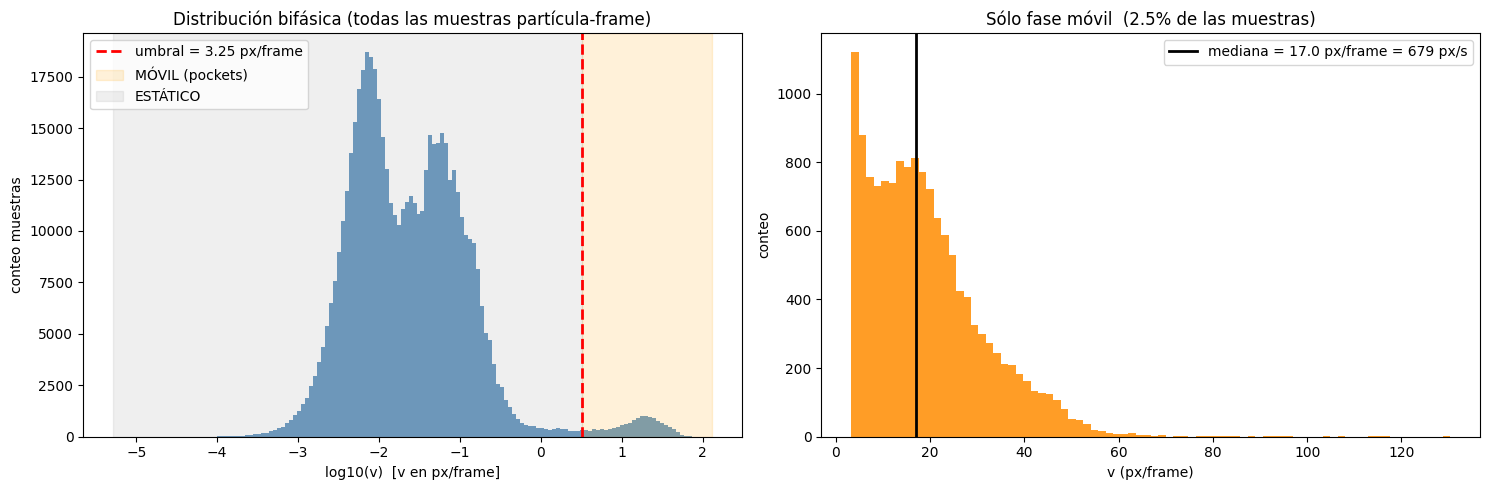

In [4]:
thr = v_valley
mob = v[v > thr]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(logv, bins=150, color='steelblue', alpha=0.8)
ax[0].axvline(np.log10(thr), color='red', ls='--', lw=2, label=f'umbral = {thr:.2f} px/frame')
ax[0].axvspan(np.log10(thr), logv.max(), color='orange', alpha=0.15, label='MÓVIL (pockets)')
ax[0].axvspan(logv.min(), np.log10(thr), color='gray', alpha=0.12, label='ESTÁTICO')
ax[0].set_xlabel('log10(v)  [v en px/frame]'); ax[0].set_ylabel('conteo muestras')
ax[0].set_title('Distribución bifásica (todas las muestras partícula-frame)')
ax[0].legend()

ax[1].hist(mob, bins=80, color='darkorange', alpha=0.85)
ax[1].axvline(np.median(mob), color='k', lw=2,
              label=f'mediana = {np.median(mob):.1f} px/frame = {np.median(mob)*FPS:.0f} px/s')
ax[1].set_xlabel('v (px/frame)'); ax[1].set_ylabel('conteo')
ax[1].set_title(f'Sólo fase móvil  ({100*len(mob)/len(v):.1f}% de las muestras)')
ax[1].legend()
plt.tight_layout(); plt.show()

## 3. Resultado: velocidad de los pockets que caen

In [5]:
print(f'umbral (valle)      : {thr:.2f} px/frame')
print(f'fracción móvil      : {100*len(mob)/len(v):.2f}% del espacio-tiempo')
print(f'mediana fase móvil  : {np.median(mob):.2f} px/frame = {np.median(mob)*FPS:.0f} px/s')
print(f'IQR                 : {np.percentile(mob,25):.1f} - {np.percentile(mob,75):.1f} px/frame')

umbral (valle)      : 3.25 px/frame
fracción móvil      : 2.55% del espacio-tiempo
mediana fase móvil  : 16.98 px/frame = 679 px/s
IQR                 : 9.7 - 25.6 px/frame


## Próximos pasos (para desarrollar juntos)

- **Segmentación por episodios**: agrupar frames móviles consecutivos de una misma partícula = paso de un pocket individual → contar avalanchas, medir duración/velocidad de cada una.
- **Mapa espacial**: velocidad de la fase móvil por posición (x, y) usando la matriz de campo.
- **Calibración px→mm**: convertir a mm/s y comparar con literatura (~500–800 mm/s en el orificio).